In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/beleeniniesta/datostrabajo/sample_submission.csv
/kaggle/input/datasets/beleeniniesta/datostrabajo/test_nolabel.csv
/kaggle/input/datasets/beleeniniesta/datostrabajo/train.csv


In [2]:
import pandas as pd
import os
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print("CARPETA:", root)
    print("ARCHIVOS:", files)
    print("------")

CARPETA: /kaggle/input
ARCHIVOS: []
------
CARPETA: /kaggle/input/datasets
ARCHIVOS: []
------
CARPETA: /kaggle/input/datasets/beleeniniesta
ARCHIVOS: []
------
CARPETA: /kaggle/input/datasets/beleeniniesta/datostrabajo
ARCHIVOS: ['sample_submission.csv', 'test_nolabel.csv', 'train.csv']
------


In [3]:
import pandas as pd

train = pd.read_csv('/kaggle/input/datasets/beleeniniesta/datostrabajo/train.csv')
test = pd.read_csv('/kaggle/input/datasets/beleeniniesta/datostrabajo/test_nolabel.csv')
sample = pd.read_csv('/kaggle/input/datasets/beleeniniesta/datostrabajo/sample_submission.csv')

train.head()

,id,LoanNr_ChkDgt,Name,City,State,Bank,BankState,ApprovalDate,ApprovalFY,NoEmp,...,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,DisbursementDate,DisbursementGross,BalanceGross,Accept
0,64afe857c28,9448323000,MIDWEST CRANKSHAFT & ENGINE,HARVEY,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,9-Aug-96,1996,28,...,0,0,1,0,N,N,31-Mar-97,"$600,000.00",$0.00,0
1,1705a7346c2,2854405007,"Iredesign, Limited",CHICAGO,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,10-Dec-07,2008,1,...,1,1,0,1,N,N,31-Dec-07,"$25,400.00",$0.00,1
2,7439801ad8a,9300423010,PHILLY'S INC.,ROCHELLE,IL,BMO HARRIS BK NATL ASSOC,IL,23-May-96,1996,6,...,0,0,1,0,N,Y,30-Sep-96,"$20,000.00",$0.00,1
3,a3f8f9d0611,4349265000,USA Laser Imaging Inc.,Loves park,IL,ALPINE BANK & TRUST CO.,IL,4-Nov-10,2011,5,...,0,5,0,1,N,N,1-Mar-11,"$75,000.00",$0.00,1
4,71e4f243b5d,2433905006,"Dan Morrell, Inc.",LISLE,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,3-May-07,2007,3,...,1,3,0,1,N,N,31-May-07,"$50,000.00",$0.00,0


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20768 entries, 0 to 20767
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 20768 non-null  object 
 1   LoanNr_ChkDgt      20768 non-null  int64  
 2   Name               20768 non-null  object 
 3   City               20767 non-null  object 
 4   State              20768 non-null  object 
 5   Bank               20713 non-null  object 
 6   BankState          20711 non-null  object 
 7   ApprovalDate       20768 non-null  object 
 8   ApprovalFY         20768 non-null  object 
 9   NoEmp              20768 non-null  int64  
 10  NewExist           20765 non-null  float64
 11  CreateJob          20768 non-null  int64  
 12  RetainedJob        20768 non-null  int64  
 13  FranchiseCode      20768 non-null  int64  
 14  UrbanRural         20768 non-null  int64  
 15  RevLineCr          20642 non-null  object 
 16  LowDoc             207

In [5]:
df = train.copy()
df.shape
df.columns
df.info()
df['Accept'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20768 entries, 0 to 20767
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 20768 non-null  object 
 1   LoanNr_ChkDgt      20768 non-null  int64  
 2   Name               20768 non-null  object 
 3   City               20767 non-null  object 
 4   State              20768 non-null  object 
 5   Bank               20713 non-null  object 
 6   BankState          20711 non-null  object 
 7   ApprovalDate       20768 non-null  object 
 8   ApprovalFY         20768 non-null  object 
 9   NoEmp              20768 non-null  int64  
 10  NewExist           20765 non-null  float64
 11  CreateJob          20768 non-null  int64  
 12  RetainedJob        20768 non-null  int64  
 13  FranchiseCode      20768 non-null  int64  
 14  UrbanRural         20768 non-null  int64  
 15  RevLineCr          20642 non-null  object 
 16  LowDoc             207

Accept
1    0.771331
0    0.228669
Name: proportion, dtype: float64

In [6]:
#Eliminar variables de identificadores no necesarias
cols_drop = ['id', 'LoanNr_ChkDgt', 'Name']
df = df.drop(columns=cols_drop, errors='ignore')

#Convertir object->moneda
money_cols = ['DisbursementGross', 'BalanceGross']

for col in money_cols:
    df[col] = df[col].replace(r'[\$,]', '', regex=True).astype(float)
    
#Convertir object->fecha
df['ApprovalDate'] = pd.to_datetime(df['ApprovalDate'], errors='coerce', dayfirst=True)
df['DisbursementDate'] = pd.to_datetime(df['DisbursementDate'], errors='coerce', dayfirst=True)
df['ApprovalYear'] = df['ApprovalDate'].dt.year
df['ApprovalMonth'] = df['ApprovalDate'].dt.month
df['DisbursementYear'] = df['DisbursementDate'].dt.year
df['DisbursementMonth'] = df['DisbursementDate'].dt.month
df = df.drop(columns=['ApprovalDate', 'DisbursementDate'], errors='ignore')

/tmp/ipykernel_55/2169502251.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ApprovalDate'] = pd.to_datetime(df['ApprovalDate'], errors='coerce', dayfirst=True)
/tmp/ipykernel_55/2169502251.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DisbursementDate'] = pd.to_datetime(df['DisbursementDate'], errors='coerce', dayfirst=True)


In [7]:
import numpy as np

# -------- LOWDOC --------
df['LowDoc'] = train['LowDoc']
df['LowDoc'] = df['LowDoc'].astype('string').str.strip().str.upper()
df['LowDoc'] = df['LowDoc'].map({'Y': 1, 'N': 0})
df['LowDoc'] = df['LowDoc'].fillna(df['LowDoc'].mode().iloc[0]).astype(int)

# -------- REVLINECR --------
df['RevLineCr'] = train['RevLineCr']
df['RevLineCr'] = df['RevLineCr'].astype('string').str.strip().str.upper()
df['RevLineCr'] = df['RevLineCr'].map({'Y': 1, 'N': 0})
df['RevLineCr'] = df['RevLineCr'].fillna(df['RevLineCr'].mode().iloc[0]).astype(int)

# -------- NEWEXIST --------
df['NewExist'] = train['NewExist']
df['NewExist'] = df['NewExist'].fillna(df['NewExist'].mode().iloc[0]).astype(int)

# -------- CATEGÓRICAS CON NULOS --------
for col in ['City', 'Bank', 'BankState']:
    df[col] = df[col].fillna('Unknown')

# -------- FECHAS --------
df['ApprovalDate'] = pd.to_datetime(train['ApprovalDate'], errors='coerce')
df['DisbursementDate'] = pd.to_datetime(train['DisbursementDate'], errors='coerce')

df['ApprovalYear'] = df['ApprovalDate'].dt.year
df['ApprovalMonth'] = df['ApprovalDate'].dt.month
df['DisbursementYear'] = df['DisbursementDate'].dt.year
df['DisbursementMonth'] = df['DisbursementDate'].dt.month

# imputar fechas
for col in ['ApprovalYear', 'ApprovalMonth', 'DisbursementYear', 'DisbursementMonth']:
    df[col] = df[col].fillna(df[col].median()).astype(int)

# eliminar originales
df = df.drop(columns=['ApprovalDate', 'DisbursementDate'], errors='ignore')

# -------- COMPROBACIÓN FINAL --------
print("Valores nulos restantes:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nInfo final:")
df.info()

/tmp/ipykernel_55/3544914938.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ApprovalDate'] = pd.to_datetime(train['ApprovalDate'], errors='coerce')


Valores nulos restantes:
Series([], dtype: int64)

Info final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20768 entries, 0 to 20767
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               20768 non-null  object 
 1   State              20768 non-null  object 
 2   Bank               20768 non-null  object 
 3   BankState          20768 non-null  object 
 4   ApprovalFY         20768 non-null  object 
 5   NoEmp              20768 non-null  int64  
 6   NewExist           20768 non-null  int64  
 7   CreateJob          20768 non-null  int64  
 8   RetainedJob        20768 non-null  int64  
 9   FranchiseCode      20768 non-null  int64  
 10  UrbanRural         20768 non-null  int64  
 11  RevLineCr          20768 non-null  int64  
 12  LowDoc             20768 non-null  int64  
 13  DisbursementGross  20768 non-null  float64
 14  BalanceGross       20768 non-null  float64
 15  Accept 

/tmp/ipykernel_55/3544914938.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DisbursementDate'] = pd.to_datetime(train['DisbursementDate'], errors='coerce')


20.768 observaciones, 21 variables
Hay muchas más aprobaciones que rechazos, El modelo podría “hacer trampa” prediciendo siempre 1 usar F1-score o ROC-AUC, no solo accuracy.
13 variables tipo object que hay que codificar.


In [8]:
# separar variables y objetivo
X = df.drop(columns=['Accept'])
y = df['Accept']

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("\nColumnas:")
print(X.columns.tolist())

Shape de X: (20768, 19)
Shape de y: (20768,)

Columnas:
['City', 'State', 'Bank', 'BankState', 'ApprovalFY', 'NoEmp', 'NewExist', 'CreateJob', 'RetainedJob', 'FranchiseCode', 'UrbanRural', 'RevLineCr', 'LowDoc', 'DisbursementGross', 'BalanceGross', 'ApprovalYear', 'ApprovalMonth', 'DisbursementYear', 'DisbursementMonth']


In [9]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Shape de X codificado:", X_encoded.shape)
X_encoded.head()

Shape de X codificado: (20768, 2062)


,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,DisbursementGross,BalanceGross,...,ApprovalFY_2005,ApprovalFY_2006,ApprovalFY_2007,ApprovalFY_2008,ApprovalFY_2009,ApprovalFY_2010,ApprovalFY_2011,ApprovalFY_2012,ApprovalFY_2013,ApprovalFY_2014
0,28,1,0,0,1,0,0,0,600000.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,1,2,1,1,0,1,0,0,25400.0,0.0,...,False,False,False,True,False,False,False,False,False,False
2,6,2,0,0,1,0,0,1,20000.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,5,2,0,5,0,1,0,0,75000.0,0.0,...,False,False,False,False,False,False,True,False,False,False
4,3,1,1,3,0,1,0,0,50000.0,0.0,...,False,False,True,False,False,False,False,False,False,False


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_val.shape)

(16614, 2062) (4154, 2062)


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

model_base = RandomForestClassifier(random_state=42, n_estimators=200)
model_base.fit(X_train, y_train)

pred_base = model_base.predict(X_val)
prob_base = model_base.predict_proba(X_val)[:, 1]

print("MODELO BASE")
print("Accuracy:", accuracy_score(y_val, pred_base))
print("F1:", f1_score(y_val, pred_base))
print("ROC-AUC:", roc_auc_score(y_val, prob_base))
print("\nClassification report:\n")
print(classification_report(y_val, pred_base))

MODELO BASE
Accuracy: 0.8271545498314877
F1: 0.8937240970988751
ROC-AUC: 0.8281253696037847

Classification report:

              precision    recall  f1-score   support

           0       0.69      0.44      0.54       950
           1       0.85      0.94      0.89      3204

    accuracy                           0.83      4154
   macro avg       0.77      0.69      0.72      4154
weighted avg       0.81      0.83      0.81      4154



In [12]:
import pandas as pd

importancias = pd.Series(model_base.feature_importances_, index=X_encoded.columns)
importancias = importancias.sort_values(ascending=False)

print("TOP 20 VARIABLES MÁS IMPORTANTES")
print(importancias.head(20))

TOP 20 VARIABLES MÁS IMPORTANTES
DisbursementGross                      0.089923
NoEmp                                  0.056259
ApprovalMonth                          0.053397
DisbursementYear                       0.052073
DisbursementMonth                      0.051870
RetainedJob                            0.049792
ApprovalYear                           0.047040
CreateJob                              0.034961
FranchiseCode                          0.028361
BankState_IL                           0.018873
NewExist                               0.017199
UrbanRural                             0.013935
City_CHICAGO                           0.013845
RevLineCr                              0.013277
BankState_CA                           0.013127
ApprovalFY_2007                        0.009981
Bank_BBCN BANK                         0.009418
ApprovalFY_2006                        0.008509
Bank_JPMORGAN CHASE BANK NATL ASSOC    0.007516
BankState_DE                           0.007191
dtype: 

In [13]:
print("VARIABLES CON MENOR IMPORTANCIA")
print(importancias.tail(20))

VARIABLES CON MENOR IMPORTANCIA
Bank_BANK OF PALATINE           0.0
City_Kingston                   0.0
City_CARBON CLIFF               0.0
Bank_BANK OF THE SOUTHWEST      0.0
City_Hoopeston                  0.0
City_JEFFERSON                  0.0
City_INDIAN HEAD PARK           0.0
Bank_BANK OF QUINCY             0.0
Bank_CASEY STATE BANK           0.0
Bank_COMMUNITY STATE BANK       0.0
City_KINCAID                    0.0
City_RANTDUL                    0.0
City_ROLLING MEAD               0.0
BankState_NJ                    0.0
BankState_NM                    0.0
City_COLLINSVILLD               0.0
City_CONTON                     0.0
BalanceGross                    0.0
City_217 EAST HANOVER STREET    0.0
City_ANNAWAN                    0.0
dtype: float64


In [14]:
X_sin_city_bank = df.drop(columns=['Accept', 'City', 'Bank'])
X_sin_city_bank = pd.get_dummies(X_sin_city_bank, drop_first=True)

X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_sin_city_bank, y, test_size=0.2, random_state=42, stratify=y
)

model_2 = RandomForestClassifier(random_state=42, n_estimators=200)
model_2.fit(X_train2, y_train2)

pred_2 = model_2.predict(X_val2)
prob_2 = model_2.predict_proba(X_val2)[:, 1]

print("MODELO SIN CITY Y BANK")
print("Accuracy:", accuracy_score(y_val2, pred_2))
print("F1:", f1_score(y_val2, pred_2))
print("ROC-AUC:", roc_auc_score(y_val2, prob_2))

MODELO SIN CITY Y BANK
Accuracy: 0.8160808858931151
F1: 0.8864447086801427
ROC-AUC: 0.7952202838557066


In [15]:
X_sin_geo = df.drop(columns=['Accept', 'City', 'Bank', 'BankState'])
X_sin_geo = pd.get_dummies(X_sin_geo, drop_first=True)

X_train3, X_val3, y_train3, y_val3 = train_test_split(
    X_sin_geo, y, test_size=0.2, random_state=42, stratify=y
)

model_3 = RandomForestClassifier(random_state=42, n_estimators=200)
model_3.fit(X_train3, y_train3)

pred_3 = model_3.predict(X_val3)
prob_3 = model_3.predict_proba(X_val3)[:, 1]

print("MODELO SIN CITY, BANK Y BANKSTATE")
print("Accuracy:", accuracy_score(y_val3, pred_3))
print("F1:", f1_score(y_val3, pred_3))
print("ROC-AUC:", roc_auc_score(y_val3, prob_3))

MODELO SIN CITY, BANK Y BANKSTATE
Accuracy: 0.800433317284545
F1: 0.8771305765525419
ROC-AUC: 0.7687978842236678


In [16]:
X_sin_fechas_detalle = df.drop(columns=[
    'Accept', 'City', 'Bank', 'BankState',
    'ApprovalMonth', 'DisbursementMonth'
])
X_sin_fechas_detalle = pd.get_dummies(X_sin_fechas_detalle, drop_first=True)

X_train4, X_val4, y_train4, y_val4 = train_test_split(
    X_sin_fechas_detalle, y, test_size=0.2, random_state=42, stratify=y
)

model_4 = RandomForestClassifier(random_state=42, n_estimators=200)
model_4.fit(X_train4, y_train4)

pred_4 = model_4.predict(X_val4)
prob_4 = model_4.predict_proba(X_val4)[:, 1]

print("MODELO SIN CITY, BANK, BANKSTATE, APPROVALMONTH, DISBURSEMENTMONTH")
print("Accuracy:", accuracy_score(y_val4, pred_4))
print("F1:", f1_score(y_val4, pred_4))
print("ROC-AUC:", roc_auc_score(y_val4, prob_4))

MODELO SIN CITY, BANK, BANKSTATE, APPROVALMONTH, DISBURSEMENTMONTH
Accuracy: 0.7804525758305247
F1: 0.8634321653189577
ROC-AUC: 0.7424035744792693


In [17]:
import numpy as np
import pandas as pd

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Variables numéricas:")
print(num_cols)

Variables numéricas:
Index(['NoEmp', 'NewExist', 'CreateJob', 'RetainedJob', 'FranchiseCode',
       'UrbanRural', 'RevLineCr', 'LowDoc', 'DisbursementGross',
       'BalanceGross', 'Accept', 'ApprovalYear', 'ApprovalMonth',
       'DisbursementYear', 'DisbursementMonth'],
      dtype='object')


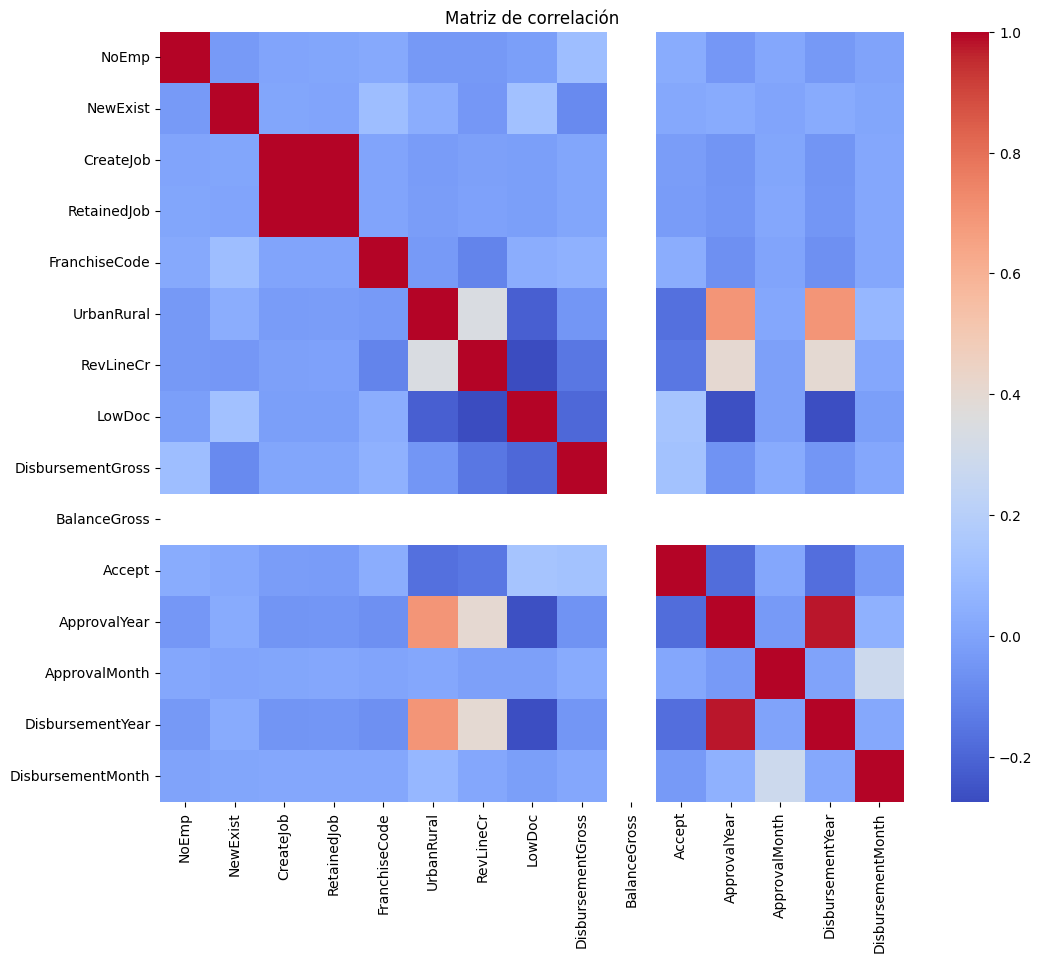

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', annot=False)
plt.title("Matriz de correlación")
plt.show()

In [19]:
corr = df[num_cols].corr().abs()

high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

print("Correlaciones más altas:")
print(high_corr.head(15))

Correlaciones más altas:
CreateJob      RetainedJob          0.997801
ApprovalYear   DisbursementYear     0.977666
UrbanRural     ApprovalYear         0.694239
               DisbursementYear     0.693621
RevLineCr      ApprovalYear         0.402769
               DisbursementYear     0.400923
UrbanRural     RevLineCr            0.343743
ApprovalMonth  DisbursementMonth    0.286916
RevLineCr      LowDoc               0.274938
LowDoc         DisbursementYear     0.267114
               ApprovalYear         0.264898
UrbanRural     LowDoc               0.216353
LowDoc         DisbursementGross    0.192468
Accept         ApprovalYear         0.178761
               DisbursementYear     0.173431
dtype: float64


In [20]:
df['TotalJobs'] = df['CreateJob'] + df['RetainedJob']

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

X_full = df.drop(columns=['Accept'])
y = df['Accept']

X_full = pd.get_dummies(X_full, drop_first=True)

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

model_full = RandomForestClassifier(random_state=42, n_estimators=200)
model_full.fit(X_train, y_train)

pred_full = model_full.predict(X_val)
prob_full = model_full.predict_proba(X_val)[:,1]

print("MODELO COMPLETO")
print("Accuracy:", accuracy_score(y_val, pred_full))
print("F1:", f1_score(y_val, pred_full))
print("ROC-AUC:", roc_auc_score(y_val, prob_full))

MODELO COMPLETO
Accuracy: 0.8230621088107848
F1: 0.8913204199319829
ROC-AUC: 0.8258310335764505


In [22]:
X_reducido = df.drop(columns=[
    'Accept',
    'CreateJob',
    'RetainedJob',
    'ApprovalMonth',
    'DisbursementMonth'
])

X_reducido = pd.get_dummies(X_reducido, drop_first=True)

X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_reducido, y, test_size=0.2, random_state=42, stratify=y
)

model_red = RandomForestClassifier(random_state=42, n_estimators=200)
model_red.fit(X_train2, y_train2)

pred_red = model_red.predict(X_val2)
prob_red = model_red.predict_proba(X_val2)[:,1]

print("MODELO REDUCIDO")
print("Accuracy:", accuracy_score(y_val2, pred_red))
print("F1:", f1_score(y_val2, pred_red))
print("ROC-AUC:", roc_auc_score(y_val2, prob_red))

MODELO REDUCIDO
Accuracy: 0.8247472315840154
F1: 0.8917311124330756
ROC-AUC: 0.8272159800249688


In [23]:
X_comb = df.drop(columns=[
    'Accept',
    'CreateJob',
    'RetainedJob'
])

X_comb = pd.get_dummies(X_comb, drop_first=True)

X_train3, X_val3, y_train3, y_val3 = train_test_split(
    X_comb, y, test_size=0.2, random_state=42, stratify=y
)

model_comb = RandomForestClassifier(random_state=42, n_estimators=200)
model_comb.fit(X_train3, y_train3)

pred_comb = model_comb.predict(X_val3)
prob_comb = model_comb.predict_proba(X_val3)[:,1]

print("MODELO CON TotalJobs")
print("Accuracy:", accuracy_score(y_val3, pred_comb))
print("F1:", f1_score(y_val3, pred_comb))
print("ROC-AUC:", roc_auc_score(y_val3, prob_comb))

MODELO CON TotalJobs
Accuracy: 0.826432354357246
F1: 0.8929472902746844
ROC-AUC: 0.8276595045666602


CreateJob – RetainedJob → 0.9978, son practicamente lo mismo
ApprovalYear – DisbursementYear → 0.9776, tambien son practicamente lo mismo
Con TotalJobs (combinando CreateJob + RetainedJob) se obtiene un accuracy mayor
Mantener → ApprovalYear
Eliminar ApprovalMonth y DisbursementMonth

In [24]:
(df['BalanceGross'] == 0).all()

np.True_

In [25]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# =========================
# 1. COPIA DEL DATASET
# =========================
df_limpio = df.copy()

# =========================
# 2. ELIMINAR DisbursementDate
# =========================
if 'DisbursementDate' in df_limpio.columns:
    df_limpio = df_limpio.drop(columns=['DisbursementDate'])

# =========================
# 3. ELIMINAR BalanceGross SI TODO ES 0
# =========================
if 'BalanceGross' in df_limpio.columns:
    if df_limpio['BalanceGross'].fillna(0).eq(0).all():
        df_limpio = df_limpio.drop(columns=['BalanceGross'])
        print("BalanceGross eliminada porque todos sus valores son 0")
    else:
        print("BalanceGross NO se ha eliminado porque tiene valores distintos de 0")

# =========================
# 4. ASEGURAR QUE Accept SEA NUMÉRICA
# =========================
if 'Accept' in df_limpio.columns:
    df_limpio['Accept'] = pd.to_numeric(df_limpio['Accept'], errors='coerce')

# =========================
# 5A. DATASET CON ESTANDARIZACIÓN
# =========================
df_estandarizado = df_limpio.copy()

if 'DisbursementGross' in df_estandarizado.columns:
    scaler_std = StandardScaler()
    df_estandarizado['DisbursementGross'] = scaler_std.fit_transform(
        df_estandarizado[['DisbursementGross']]
    )

# =========================
# 5B. DATASET CON NORMALIZACIÓN
# =========================
df_normalizado = df_limpio.copy()

if 'DisbursementGross' in df_normalizado.columns:
    scaler_norm = MinMaxScaler()
    df_normalizado['DisbursementGross'] = scaler_norm.fit_transform(
        df_normalizado[['DisbursementGross']]
    )

# =========================
# 6. VER RESULTADOS
# =========================
print("Dataset base limpio:")
print(df_limpio.head())

print("\nDataset con DisbursementGross estandarizada:")
print(df_estandarizado.head())

print("\nDataset con DisbursementGross normalizada:")
print(df_normalizado.head())

BalanceGross eliminada porque todos sus valores son 0
Dataset base limpio:
         City State                            Bank BankState ApprovalFY  \
0      HARVEY    IL  JPMORGAN CHASE BANK NATL ASSOC        IL       1996   
1     CHICAGO    IL  JPMORGAN CHASE BANK NATL ASSOC        IL       2008   
2    ROCHELLE    IL        BMO HARRIS BK NATL ASSOC        IL       1996   
3  Loves park    IL         ALPINE BANK & TRUST CO.        IL       2011   
4       LISLE    IL  JPMORGAN CHASE BANK NATL ASSOC        IL       2007   

   NoEmp  NewExist  CreateJob  RetainedJob  FranchiseCode  UrbanRural  \
0     28         1          0            0              1           0   
1      1         2          1            1              0           1   
2      6         2          0            0              1           0   
3      5         2          0            5              0           1   
4      3         1          1            3              0           1   

   RevLineCr  LowDoc  Disburs

In [26]:
df['Accept'].unique()

array([0, 1])

In [28]:
"""Preprocessing utilities for the DisbursementGross column.

Paths:
- Option A: normalize values (min-max)
- Option B: standardize values (z-score)
"""

from __future__ import annotations

import pandas as pd


# Choose the default preprocessing path.
# Allowed values: "A" or "B".
DEFAULT_DISBURSEMENTGROSS_OPTION = "A"


def _to_numeric_disbursementgross(series: pd.Series) -> pd.Series:
	"""Convert DisbursementGross values to numeric.

	- Trims whitespace
	- Converts blank strings to missing
	- Coerces non-numeric values to missing
	"""
	cleaned = series.astype("string").str.strip()
	cleaned = cleaned.mask(cleaned.fillna("").eq(""), pd.NA)
	return pd.to_numeric(cleaned, errors="coerce")


def _min_max_normalize(series: pd.Series) -> pd.Series:
	"""Apply min-max normalization to a numeric series."""
	min_val = series.min(skipna=True)
	max_val = series.max(skipna=True)

	if pd.isna(min_val) or pd.isna(max_val) or min_val == max_val:
		return pd.Series(pd.NA, index=series.index, dtype="Float64")

	return ((series - min_val) / (max_val - min_val)).astype("Float64")


def _zscore_standardize(series: pd.Series) -> pd.Series:
	"""Apply z-score standardization to a numeric series."""
	mean_val = series.mean(skipna=True)
	std_val = series.std(skipna=True, ddof=0)

	if pd.isna(mean_val) or pd.isna(std_val) or std_val == 0:
		return pd.Series(pd.NA, index=series.index, dtype="Float64")

	return ((series - mean_val) / std_val).astype("Float64")


def preprocess_disbursementgross_option_a(
	df: pd.DataFrame,
	source_col: str = "DisbursementGross",
) -> pd.DataFrame:
	"""Option A preprocessing for DisbursementGross (normalize values)."""
	if source_col not in df.columns:
		raise KeyError(f"Column '{source_col}' not found in DataFrame")

	result = df.copy()
	disbursementgross_num = _to_numeric_disbursementgross(result[source_col])

	result[source_col] = disbursementgross_num
	result["disbursementgross_normalized"] = _min_max_normalize(disbursementgross_num)

	return result


def preprocess_disbursementgross_option_b(
	df: pd.DataFrame,
	source_col: str = "DisbursementGross",
) -> pd.DataFrame:
	"""Option B preprocessing for DisbursementGross (standardize values)."""
	if source_col not in df.columns:
		raise KeyError(f"Column '{source_col}' not found in DataFrame")

	result = df.copy()
	disbursementgross_num = _to_numeric_disbursementgross(result[source_col])

	result[source_col] = disbursementgross_num
	result["disbursementgross_standardized"] = _zscore_standardize(disbursementgross_num)

	return result


def preprocess_disbursementgross(
	df: pd.DataFrame,
	option: str = DEFAULT_DISBURSEMENTGROSS_OPTION,
	source_col: str = "DisbursementGross",
) -> pd.DataFrame:
	"""Dispatch DisbursementGross preprocessing based on selected option.

	Parameters
	----------
	df : pd.DataFrame
		Input dataset.
	option : str
		"A" for Option A (normalize), "B" for Option B (standardize).
	source_col : str
		Column name for DisbursementGross.
	"""
	option_upper = option.upper()

	if option_upper == "A":
		return preprocess_disbursementgross_option_a(df=df, source_col=source_col)
	if option_upper == "B":
		return preprocess_disbursementgross_option_b(df=df, source_col=source_col)

	raise ValueError("option must be 'A' or 'B'")

In [29]:
"""Preprocessing utilities for the DisbursementDate column.

Path:
- Drop the original column
"""

from __future__ import annotations

import pandas as pd


def preprocess_disbursementdate(
	df: pd.DataFrame,
	source_col: str = "DisbursementDate",
) -> pd.DataFrame:
	"""Preprocess DisbursementDate by dropping the column."""
	if source_col not in df.columns:
		raise KeyError(f"Column '{source_col}' not found in DataFrame")

	result = df.copy()
	result = result.drop(columns=[source_col])

	return result

In [31]:
"""Preprocessing utilities for the BalanceGross column.

Path:
- Drop the original column
"""

from __future__ import annotations

import pandas as pd


def preprocess_balancegross(
	df: pd.DataFrame,
	source_col: str = "BalanceGross",
) -> pd.DataFrame:
	"""Preprocess BalanceGross by dropping the column."""
	if source_col not in df.columns:
		raise KeyError(f"Column '{source_col}' not found in DataFrame")

	result = df.copy()
	result = result.drop(columns=[source_col])

	return result

In [32]:
"""Preprocessing utilities for the Accept column.

Path:
- Convert values to numeric
"""

from __future__ import annotations

import pandas as pd


def _to_numeric_accept(series: pd.Series) -> pd.Series:
	"""Convert Accept values to numeric.

	- Trims whitespace
	- Converts blank strings to missing
	- Coerces non-numeric values to missing
	"""
	cleaned = series.astype("string").str.strip()
	cleaned = cleaned.mask(cleaned.fillna("").eq(""), pd.NA)
	return pd.to_numeric(cleaned, errors="coerce")


def preprocess_accept(
	df: pd.DataFrame,
	source_col: str = "Accept",
) -> pd.DataFrame:
	"""Preprocess Accept by converting values to numeric."""
	if source_col not in df.columns:
		raise KeyError(f"Column '{source_col}' not found in DataFrame")

	result = df.copy()
	result[source_col] = _to_numeric_accept(result[source_col])

	return result